<a href="https://colab.research.google.com/github/jomanakhatib/Projects-/blob/main/ML_AI_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML/AI Assignment

Jomana Mohamed Magdy Youssef Khatib

Senior Business Informatics studnet at the GUC

Data Modelling

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# ===========================================
# 1. LOAD DATA
# ===========================================
df = pd.read_csv("oil_sales_assignment_dataset.csv")
print("\nDataset Loaded. Shape:", df.shape)
print(df.head())

# ===========================================
# 2. DATA PREPROCESSING (WITH EXPLANATION)
# ===========================================
print("\n==================== DATA PREPROCESSING ====================")

print("\nMissing values before cleaning:\n", df.isnull().sum())

# ---- Cleaning Strategy ----
# 1. Remove rows with invalid volume (0 or negative)
df = df[df["volume_sales"] > 0]

# 2. Recompute missing average_price
df["average_price"] = df.apply(
    lambda x: x["value_sales"] / x["volume_sales"]
    if pd.isnull(x["average_price"]) and x["volume_sales"] > 0
    else x["average_price"], axis=1
)

# 3. Recompute value_sales if missing
df["value_sales"] = df.apply(
    lambda x: x["average_price"] * x["volume_sales"]
    if pd.isnull(x["value_sales"]) and x["average_price"] > 0
    else x["value_sales"], axis=1
)

# Convert price bracket into midpoint numeric
def clean_price_bracket(b):
    if isinstance(b, str):
        b = b.replace("$", "")
        if "101+" in b:
            return 120
        if "-" in b:
            low, high = b.split("-")
            return (float(low) + float(high)) / 2
    return np.nan

df["price_bracket_clean"] = df["price_bracket"].apply(clean_price_bracket)

# Fill missing numerics with median & categoricals with UNKNOWN
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna("UNKNOWN", inplace=True)

print("\nMissing values AFTER cleaning:\n", df.isnull().sum())

# ---- Outlier Treatment (IQR Clipping) ----
def cap_outliers(col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

for col in ["value_sales", "volume_sales", "average_price"]:
    cap_outliers(col)

# ---- Feature Engineering ----
df["sales_per_unit"] = df["value_sales"] / df["volume_sales"]
df["size_numeric"] = df["size"].str.replace("L", "").astype(float)
df["year_month"] = df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2)

print("\nData Preprocessing Completed Successfully!")


Dataset Loaded. Shape: (2000, 13)
       city                                         store_name  \
0   AL BAHA   HM No  57296  GS-CENTER-AL BAHA MAIN RD  AL BAHA   
1  AL KHARJ  HM No  55697  GS-CENTER-AL KHARJ MAIN RD  AL K...   
2    RIYADH     HM No  86781  GS-CENTER-RIYADH MAIN RD  RIYADH   
3    DAMMAM     HM No  95753  GS-CENTER-DAMMAM MAIN RD  DAMMAM   
4     JAZAN       HM No  56338  GS-CENTER-JAZAN MAIN RD  JAZAN   

          manufacturer   brand      class   size  \
0           NOVA FOODS    LARA    COCONUT  0.75L   
1   PALM & GRAIN GROUP   NAJMA     CANOLA   0.5L   
2  AL HILAL INDUSTRIES  BAYTNA  SUNFLOWER  0.75L   
3   PALM & GRAIN GROUP    NOUR       CORN   0.6L   
4        DESERT SUN CO    NOUR  VEGETABLE     1L   

                            sku price_bracket  year  month  value_sales  \
0  LARA COCONUT 0.75L TWIN PACK         21-30  2024     12       830.86   
1   NAJMA CANOLA 0.5L TWIN PACK         41-50  2024     10       373.10   
2    BAYTNA SUNFLOWER 0.75L EC


==================== MACHINE LEARNING MODELS ====================

--- Regression Model ---
MAE: 24.22113190000001
RMSE: 48.98203092838447
R²: 0.9909954353590699

--- Classification Model ---
Accuracy: 0.9825

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       198
           1       0.98      0.99      0.98       202

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



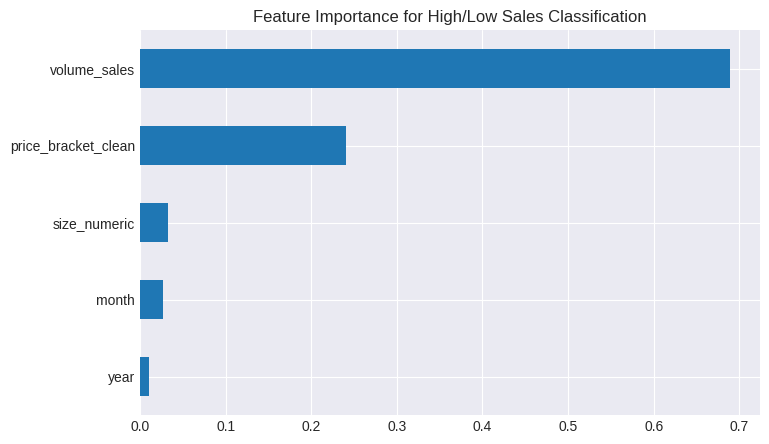


==================== VISUALIZATION OF INTENDED USE CASES ====================


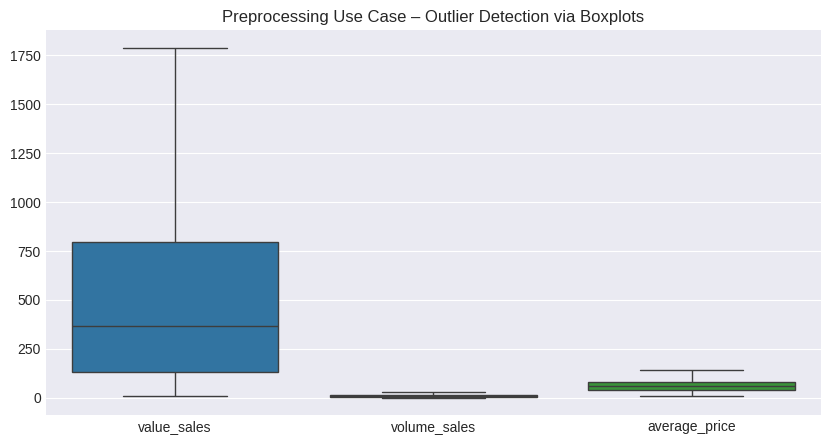

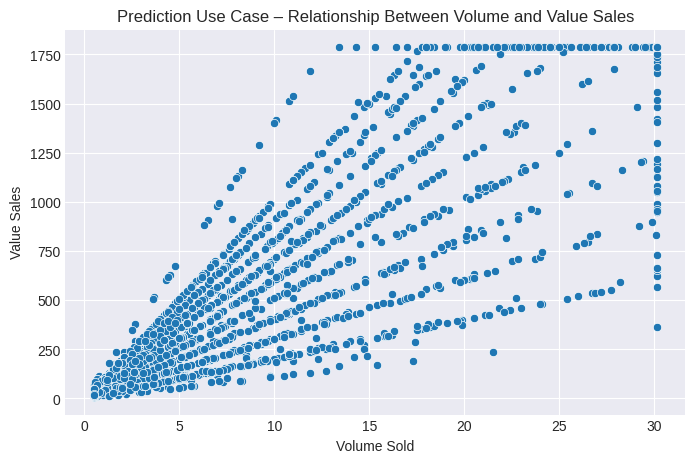

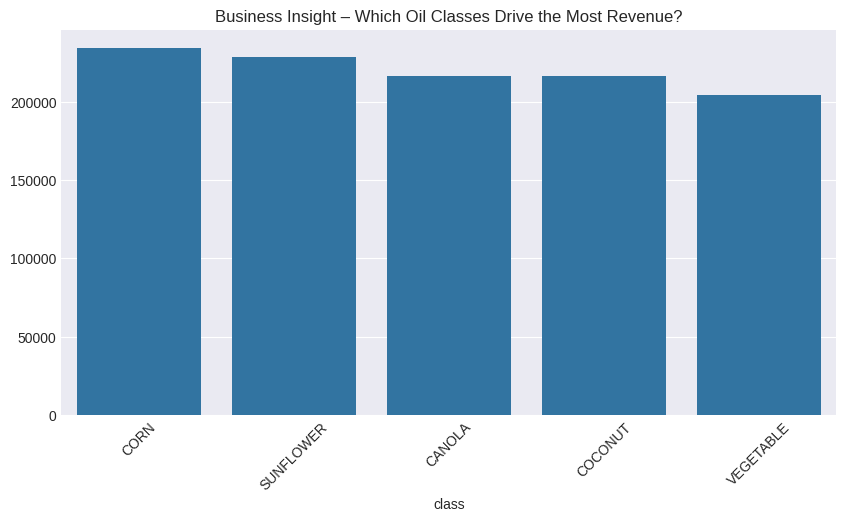

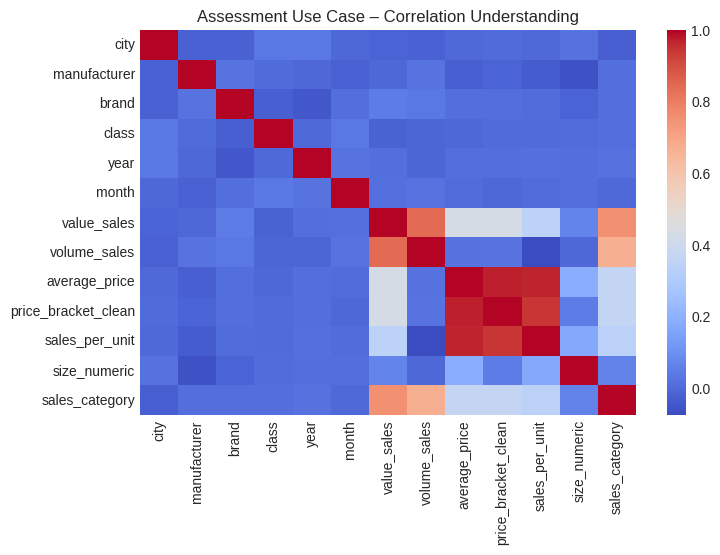


==================== ANALYSIS COMPLETE ====================


In [10]:
# =======================================================
# 4. MACHINE LEARNING MODELS
# =======================================================

print("\n==================== MACHINE LEARNING MODELS ====================")

# Encode categorical columns
le = LabelEncoder()
for col in ["city", "brand", "manufacturer", "class"]:
    df[col] = le.fit_transform(df[col])

# ---------------- Regression Model ----------------
reg_features = ["price_bracket_clean", "size_numeric", "month", "year", "volume_sales"]
X_reg = df[reg_features]
y_reg = df["value_sales"]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)

y_pred_reg = reg_model.predict(X_test)

print("\n--- Regression Model ---")
print("MAE:", mean_absolute_error(y_test, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_reg)))
print("R²:", r2_score(y_test, y_pred_reg))

# ---------------- Classification Model ----------------
df["sales_category"] = (df["value_sales"] > df["value_sales"].median()).astype(int)

clf_features = ["price_bracket_clean", "size_numeric", "month", "year", "volume_sales"]
X_clf = df[clf_features]
y_clf = df["sales_category"]

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)

y_pred_clf = clf_model.predict(X_test)

print("\n--- Classification Model ---")
print("Accuracy:", accuracy_score(y_test, y_pred_clf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_clf))

# Plot Classification Feature Importances
feat_imp = pd.Series(clf_model.feature_importances_, index=clf_features)
feat_imp.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Feature Importance for High/Low Sales Classification")
plt.show()

# =======================================================================
# 5. VISUALIZATION OF INTENDED USE CASES
# =======================================================================

print("\n==================== VISUALIZATION OF INTENDED USE CASES ====================")

# 1️ Data Preprocessing Use Case
plt.figure(figsize=(10,5))
sns.boxplot(data=df[["value_sales", "volume_sales", "average_price"]])
plt.title("Preprocessing Use Case – Outlier Detection via Boxplots")
plt.show()

# 2️. Prediction Use Case
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["volume_sales"], y=df["value_sales"])
plt.title("Prediction Use Case – Relationship Between Volume and Value Sales")
plt.xlabel("Volume Sold")
plt.ylabel("Value Sales")
plt.show()

# 3️. Business Insight Use Case
plt.figure(figsize=(10,5))
sns.barplot(x=class_sales.index, y=class_sales.values)
plt.title("Business Insight – Which Oil Classes Drive the Most Revenue?")
plt.xticks(rotation=45)
plt.show()

# 4️. Assessment Use Case (Candidate Problem Solving)
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Assessment Use Case – Correlation Understanding")
plt.show()

print("\n==================== ANALYSIS COMPLETE ====================")